### Discrete Fourier Transform 2D

To deal with images, we must extend the DFT and IDFT to 2D as follows (where $m,n$ are the spatial coordinates and $k,l$ are the frequency coordinates):

DFT2:
$$\hat f_{k,l}=\sum_{m=0}^{N-1}\sum_{n=0}^{N-1} f_{m,n} e^{-i \frac{2 \pi}{N}(km+ln)}, \ \ m,n=0, \ldots N-1 $$

IDFT2:
$$ f_{m,n}=\sum_{k=0}^{N-1}\sum_{l=0}^{N-1} \hat f_{k,l} \frac{1}{N^2} e^{i \frac{2 \pi}{N}(km+ln)}, \ \ k,l=0, \ldots N-1 $$


**How to read the DFT of an image?**

<p align="center">
  <img src="immagini_sorgente\fourier27.png"  width="600">
  <p align="center"> 
</p>

Examples.

The first image is a cosine function along x axis. The Fourier transform of a cisine function (as we have seen in 1D) is essentially one frequency (and its negative counterpart). The central point at 0 is due to the fact that the mean of the brightness is 0 (in a range [0,255] is 128 but it can be shifted to 0).

The second image is an image of a cosine function of higher frequency. We have still three dots but more separated because the frequecy has increased.

The third image is a sum of two cosine functions.

<p align="center">
  <img src="immagini_sorgente\fourier25.png"  width="600">
  <p align="center"> 
</p>

<p align="center">
  <img src="immagini_sorgente\fourier26.png"  width="400">
  <p align="center"> 
</p>


Examples with simple objects:

High frequencies are necessary to create the borders of the objects.

<p align="center">
  <img src="immagini_sorgente\fourier28.png"  width="600">
  <p align="center"> 
</p>

Examples with more natural images:

<p align="center">
  <img src="immagini_sorgente\fourier29.png"  width="600">
  <p align="center"> 
</p>

### Image filtering in the frequency domain



The values in the Fourier domain, usually called frequencies, have some useful properties for image manipulation, such as 

- Reduce the noise on the image (denoising)
- Reduce the space occupied by the image (compression)


**Denoising image with DFT**

- To denoise an image using a Fast Fourier Transform (FFT) filter, we can use a simple method of applying a low-pass filter in the frequency domain.

- The idea is to suppress high-frequency noise, which typically exists in the higher frequencies of 
the Fourier spectrum, while preserving the low-frequency components, which generally correspond to the important structure of the image.

- To reduce the ringing artifacts, you can apply a soft cutoff or smooth filter in the frequency domain. This can be done by using a smoother low-pass filter, such as a Gaussian filter or Butterworth filter, instead of a sharp circular mask. These filters gradually attenuate the high frequencies, which helps to avoid the abrupt transitions that lead to ringing.

**Parameter**: The **cutoff_frequency** defines how aggressive the denoising is. A higher value keeps more details but may allow some noise to persist, while a lower value results in stronger denoising but may also remove fine details.

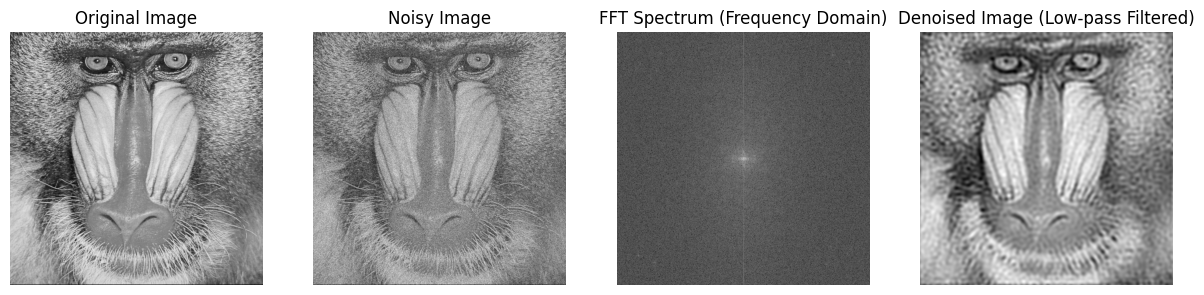

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def denoise_fft(image_path, cutoff=30):
    # 1. Load the image (grayscale for simplicity)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    

    img = img.astype(np.float64) / 255.0  # Normalizzazione
    # add gaussian noise
    
    noise = np.random.normal(0, 0.1, img.shape)
    noisy_img = img + noise
    

    # 2. FFT: Transform image to frequency domain
    # We use fftshift to move the zero-frequency component to the center
    f_transform = np.fft.fft2(noisy_img)
    f_shift = np.fft.fftshift(f_transform)

    # 3. Low-pass filter: Construct a circular mask
    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2
    y, x = np.ogrid[:rows, :cols]
    mask = ((x - ccol)**2 + (y - crow)**2 <= cutoff**2).astype(np.float64)

    # 4. Apply the filter (fshift * mask)
    f_shift_filtered = f_shift * mask

    # 5. Inverse FFT: Transform back to spatial domain
    # Shift back before performing inverse FFT
    f_ishift = np.fft.ifftshift(f_shift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back) # Get the magnitude

    # --- Visualization ---
    plt.figure(figsize=(15, 5))
    
    plt.subplot(141), plt.imshow(img, cmap='gray')
    plt.title('Original Image'), plt.axis('off')
    
    plt.subplot(143), plt.imshow(np.log(1 + np.abs(f_shift)), cmap='gray')
    plt.title('FFT Spectrum (Frequency Domain)'), plt.axis('off')
    
    plt.subplot(144), plt.imshow(img_back, cmap='gray')
    plt.title('Denoised Image (Low-pass Filtered)'), plt.axis('off')

    plt.subplot(142), plt.imshow(noisy_img, cmap='gray')
    plt.title('Noisy Image'), plt.axis('off')
    
    plt.show()

# Run the function
denoise_fft('Baboon.bmp', cutoff=50)

**Compressing images with DFT**

- The Discrete Fourier Transform (DFT) plays a significant role in image compression, a crucial process for reducing file sizes while maintaining image quality. 
- By transforming the spatial representation of an image into the frequency domain, the DFT allows us to identify and retain only the most significant frequency components, discarding less important data without a substantial loss of detail.

- Techniques such as the JPEG compression algorithm leverage this principle, using transformations similar to the DFT to efficiently encode image data. 

- By focusing on the most critical frequencies, the DFT enables significant reductions in image size, allowing for faster transmission and storage while preserving essential features.

 **Parameter: threshold**. This is the fraction of the maximum magnitude below which the 
 frequency components are discarded. You can adjust this to control the compression rate.
 A lower value will preserve more high-frequency details and result in less compression, 
 while a higher value will discard more frequencies, resulting in more compression
 


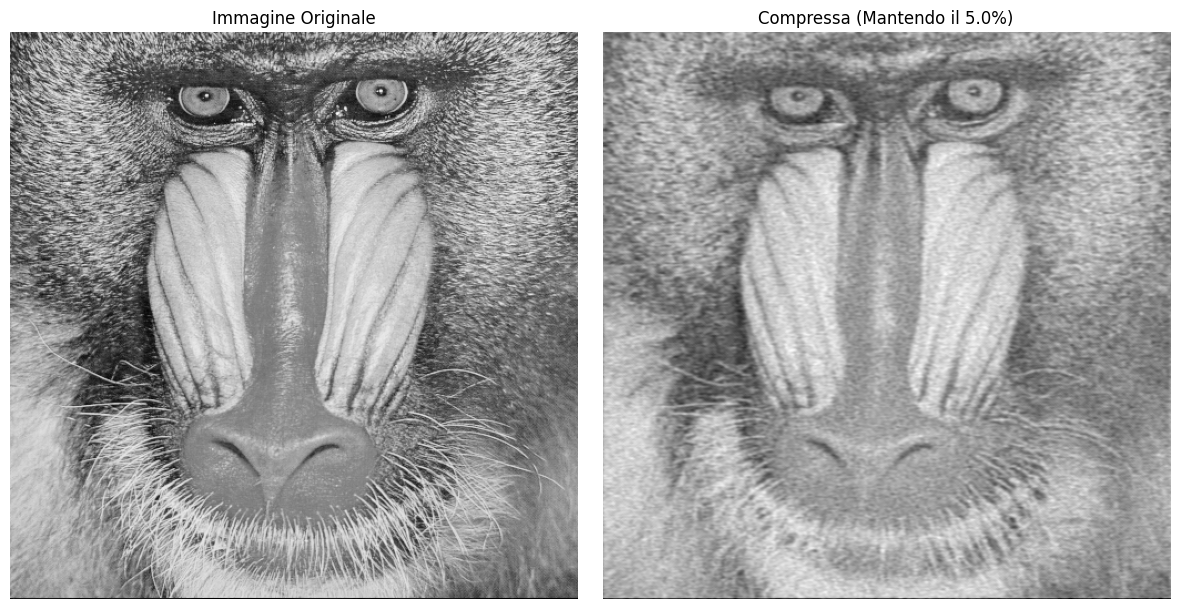

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def compress_image_fft(image_path, keep_fraction=0.1):
    # 1. Read the image (in float per precisione)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Errore: Immagine non trovata.")
        return
    img_float = img.astype(float)

    # 2. FFT: Transform the image in the frequency space
    f_transform = np.fft.fft2(img_float)
    
    # separately compte magnitude and phase
    magnitude = np.abs(f_transform)
    phase = np.angle(f_transform)

    # 3. Compression: we cut-off the low frequencies
    # and we order the magnitudes to find a threshold value
    magnitude_sorted = np.sort(magnitude.ravel())
    threshold_idx = int(len(magnitude_sorted) * (1 - keep_fraction))
    threshold_value = magnitude_sorted[threshold_idx]

    # We apply the threshold and set equal to zero every value below the threshold
    magnitude_compressed = magnitude * (magnitude > threshold_value)

    # 4. Reconstruction: 
    # we use the formula: F = Mag * e^(i * Phase)
    f_reconstructed = magnitude_compressed * np.exp(1j * phase)
    
    img_compressed = np.fft.ifft2(f_reconstructed)
    img_compressed = np.real(img_compressed) # Prendiamo la parte reale

    # 5. Display: comparison between original and compressed
    plt.figure(figsize=(12, 6))
    
    plt.subplot(121), plt.imshow(img, cmap='gray')
    plt.title('Immagine Originale'), plt.axis('off')
    
    plt.subplot(122), plt.imshow(img_compressed, cmap='gray')
    plt.title(f'Compressa (Mantendo il {keep_fraction*100}%)'), plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Example: we keep only 5% of the frequencies
compress_image_fft('baboon.bmp', keep_fraction=0.05)